# Session 2:  Parallel Processing with MsPASS
## *Gary L. Pavlis*
## *Ian Wang*

## Overview

This notebook is a hands on exercise that students will run during the second session of this class on GeoLab.   It is the second of a two-part sequence for session 2 of the class.   Part 1 focuses on fundamentals of parallel processing with dask.  This notebook focuses exclusively on constructing seismic processing workflows.   We first run an example serial workflow.  We then see how to transform that serial workflow into a parallel one.   In the process we will dig deeper into dask diagnostics while monitoring the processing in real time.   We then compare that to the same job run with the new sliding_window_pipeline function added to MsPASS a few months ago.  

The learning objective of this tutorial are:
1.  Understand the basic structure of the most common seismic processing workflows
2.  Understand how to convert a prototype serial workflow into a parallel one with map/reduce.
3.  Understand the Futures approach to parallel processing
4.  Understand what a pipeline workflow is and how to use the sliding_window_pipeline function of MsPASS instead of map-reduce.

Note:  MsPASS supports two different "schedulers" for handling parallel processing:  (1) dask, and (2) spark (technically pyspark).  We will only use the default scheduler for MsPASS, dask, for this class for a number of reasons that are not worth relating as it would only confuse the issues.  Most importantly, spark currently lacks a Futures interface needed to implement the sliding_window_pipeline we will utilize in this tutorial.

## Before Running this Notebook
### Launch the database server

As noted in the PrecourseProcessing notebook, an issue we haven't been able to resolve is how to have a private instance of MongoDB launch for each instance of a geolab login.  For that reason you will need to do a shortened version of the commands you used in the PrecourseProcessing notebook.  

Launch a terminal window in GeoLab and enter these commands:
```
cd   #  makes sure you are running this in your home directory
mongod --dbpath ./db --logpath ./logs/mongo_log
```
Note a couple things that can go wrong here:
-  The command will block.  If you want to reuse that terminal window put an & at the end of the mongod launch line.
-  DO NOT exit the terminal window from which you run the mongod command or you will kill the database server.  
-  Each time you reconnect to GeoLab you will need to relaunch the MonogDB server with that  incantation. Be careful you always run the command from the same directory as that way the database files will be written to ~/db and the mongodb log will appear in ~/logs.
-  In all cases it is wise to launch a second Terminal window and verify that worked by typing `ps -A`  You should see a line where the CMD field is "mongod".   If not, contact me by email or slack if you are unable to solve the problem.  The first place to look if you are having a problem is the content of the file ~/logs/mongo_log that will be generated when this command runs.


## Initializations
First, the stock incantation that most MsPASS workflows should use for initialization.   

In [1]:
from mspasspy.db.database import Database
import mspasspy.client as msc
mspass_client = msc.Client()
dask_client = mspass_client.get_scheduler()
db = mspass_client.get_database("ES2026")

2026-07-01 19:33:21,757 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='geolab.earthscope.cloud', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/tornado/websocket.py", line 938, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/opt/conda/lib/python3.10/site-packages/tornado/web.py", line 3301, in wrapper
    return method(self, *args, **kwargs)
  File "/opt/conda/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary
2026-07-01 19:33:30,814 - tornado.application - ERROR -

Number live entering stack_ensemble= 182
Number live entering stack_ensemble= 396
Number live entering stack_ensemble= 393
Number live entering stack_ensemble= 394
Number live entering stack_ensemble= 345
Number live entering stack_ensemble= 397
Number live entering stack_ensemble= 407
Number live entering stack_ensemble= 11
Number live entering stack_ensemble= 38
Number live entering stack_ensemble= 403
Number live entering stack_ensemble= 407
Number live entering stack_ensemble= 398
Number live entering stack_ensemble= 372
Number live entering stack_ensemble= 7
Number live entering stack_ensemble= 341
Number live entering stack_ensemble= 2
Number live entering stack_ensemble= 14
Number live entering stack_ensemble= 405
Number live entering stack_ensemble= 235
Number live entering stack_ensemble= 397
Number live entering stack_ensemble= 399
Number live entering stack_ensemble= 258
Number live entering stack_ensemble= 400
Number live entering stack_ensemble= 373
Number live entering st

2026-07-01 21:00:39,399 - distributed.scheduler - ERROR - Removing worker 'tcp://127.0.0.1:36267' caused the cluster to lose scattered data, which can't be recovered: {'ObjectIdMatcher-8a8d92801934e4b59559efb3444d771d', 'ObjectIdMatcher-ae10e200dae67b880a1315b0c1e52bbb'} (stimulus_id='handle-worker-cleanup-1782939639.3995914')


In [2]:
dask_client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/8787/status,
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 29.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44003,Workers: 0
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33341,Total threads: 1
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/33977/status,Memory: 7.27 GiB
Nanny: tcp://127.0.0.1:44193,


First we do a series of imports needed to support the workflow.  Note common practice is that during development of a workflow in a notebook it is a good idea to keep most imports at the top like this.   As you develop the workflow it is ok to add new imports later, but for a production workflow it is preferable to move them all to the top.  The reason is maintenance as it can be confusing to know where a symbol comes from if it appears in the middle of a large notebook.  You can also get mysterious conflicts if a symbol name changes with a later import.  

In [3]:
from mspasspy.algorithms.window import WindowData,scale
from mspasspy.algorithms.basic import ator,ExtractComponent,rotate_to_standard
from mspasspy.ccore.algorithms.basic import TimeWindow
from mspasspy.ccore.utility import ErrorSeverity
from mspasspy.db.normalize import ObjectIdMatcher,normalize
from mspasspy.algorithms.signals import filter,detrend
import matplotlib.pyplot as plt
from mspasspy.graphics import SeismicPlotter
from obspy import UTCDateTime
import time

## Serial Prototype
### Overview
Although one of most important features of MsPASS is it's integrated, generic parallel processing functionality I would assert all users of MsPASS need to internalize two axioms:

1.  Always prototype your workflow as a serial process as the first step.
2.  Only convert that workflow to a parallel workflow if necessary to make the computations feasible.

I will blab more about those two points in the lecture associated with this notebook, but you should view this section of the notebook as an example of item 1.  It also includes simple examples of getting performance data to establish how essential parallel processing is to complete the task.

### Optional Aside
To fully understand the serial workflow we will run below it is helpful, although not essential, to understand these key concepts:

-  The generic concept of a "object" in modern computing and what we mean in MsPASS by a "data object"
-  MsPASS defines the concept of a `Seismogram` object as a container holding the combined channels from a three-component sensor set.
-  A `Seismogram` object has a set of methods that simplify coordinate transformations (e.g. things like rotation to radial, transverse, and vertical from EW, NS, and Z)

The details of what that means are important, but are an aside from the primary topic of today: parallel processing.   Consequently, an asignment for all students in this course is to read through and run the notebook you will find in this directory called "SeismogramAside.ipynb" as part of the homework before the final session of the class.   That tutorial aims to help you better understand those concepts encapsulated in a `Seismogram` object.  For the rest of this session all you really need to know is:
1.  A `Seismogram` is data we will be handling.
2.  You created a bunch of these when you ran the precourse notebooks.
3.  The objects we will be working will be constructed by using readers in the MsPASS database API.
4.  We will be saving the results of calculations to the MsPASS database using different methods of the database API.

### Generic Structure of a Serial Workflow
MsPASS serial workflows nearly always reduce to this pseudocode structure:
```
  1) import all required modules and functions
  2) define all custom python processing functions
  3) create a database query list OR a virtual list with a MongoDB CommandCursor
  4) foreach entry in list:
     5)  read data object from database using entry
     6)  run a series of processing functions on this datum
     7)  save the result to the database using a "data_tag" to identify what it is
```
That hides a lot of details, but I'll use those number tags and refer back to them as we examine the tutorial workflow we will be running momentarily.   

We already did part of 1), but we'll need to add a few.   That is typically how a serial workflow evolves - you know which ones at first you know you will need and then you add additional imports as you realize you need them.  I left them in this form for educational purposes, but reiterate if I were creating this for a major processing sequence I'd aim to move all the imports to the top of the notebook.

Now we are at part 2).  There are a lot of details, but you first need to understand what processing we are aiming to do.   i.e. we need to define some functions needed to create generic step 6 above.  To understand what is defined below here is a summary of what the processing steps later will need to do:

- Align the data to P wave pick times made by the Earthscope ANF analysts (i.e. make time 0 be the measured P wave arrival time)
- Remove the dc offset of the signal with the detrend function
- Make certain the Seismograms are in standard coordinates (E,N,Z)
- Apply Kennett's free surface transformation (see "SeismogramAside" notebook and/or ask your favorite AI for background) to the data
- Extract the "longitudinal component"
- Stack the longitudinal component data (create a "beam" in array processing jargon)

There are a few some metadata manipulation steps we'll need to do as well, but those are best understood when we get to the actual processing code.  You should also note that if you are developing a new workflow good practice is to use a markdown box like this to write a pseudocode version of the processing sequence you will then translate into actual python code.  

With understanding there are then two things in that list that are not part of MsPASS.  I urge you to just run this next cell to define two functions we will need.  You will see how they are used shortly.   You should also skim the docstrings as they explain what the functions do as awell.  The key point is to realize these two function implement a functionality not wired into MsPASS.   Most workflows will need to create a set of custom functions like this to handle something unique to your problem.   That is actually a very very good thing compared to something like SAC.   The python language is infinitely more flexible than a primitive job control language like SAC's interpreter.   The flexibility of python allows you to implement new approaches that would be impossible with a dinosaur like SAC. 

In [4]:
import math
from mspasspy.ccore.seismic import SlownessVector
from mspasspy.algorithms.basic import free_surface_transformation
from mspasspy.ccore.utility import ErrorSeverity
from obspy.taup import TauPyModel
from obspy.geodetics.base import gps2dist_azimuth,kilometers2degrees

def set_PStime(d,
               Ptimekey="Ptime",
               Stimekey="Stime",
               model=None,
               receiver_collection="site",
              ):
    """
    Function to calculate P and S wave arrival time and set times 
    as the header (Metadata) fields defined by Ptimekey and Stimekey.
    Tries to handle some complexities of the travel time calculator 
    returns when one or both P and S aren't calculatable.  That is 
    the norm in or at the edge of the core shadow.  
    Requires source and receiver coordinates stored in the Metadata 
    of d.  Required source data is frozen as "source_lat", 
    "source_lon", "source_depth", and "source_time".   Receiver 
    data is similar but depends upon the value of `receiver_collection`.
    (see below).  If any of that required metadata is missing the 
    return will be killed with a message posted to elog.  
    
    :param d:  input TimeSeries datum.  Assumes datum's Metadata 
      contains stock source and channel attributes.  
    :param Ptimekey:  key used to define the header attribute that 
      will contain the computed P time.  Default "Ptime".
    :param model:  instance of obspy TauPyModel travel time engine. 
      Default is None.   That mode is slow as an new engine will be
      constructed on each call to the function.  Normal use should 
      pass an instance for greater efficiency.  
    :param receiver_collection:   normalizing collection used to 
      load receiver metadata.   In MsPASS normalizing attributes 
      are (by default) loaded with a prefix defining the collection 
      the came from.   The default for this argument is "site" which 
      means the function will attempt to fetch receiver location 
      data with the keys "site_lat" and "site_lon"  
    """
    if d.live:
        if model is None:
            model = TauPyModel(model="iasp91") 
        rlatkey=f"{receiver_collection}_lat"
        rlonkey=f"{receiver_collection}_lon"
        required_keys=["source_lat","source_lon","source_depth","source_time"]
        required_keys.append(rlatkey)
        required_keys.append(rlonkey)
        message = ""
        for key in required_keys:
            if key not in required_keys:
                message += "Missing required key={}\n".format(key)
        if len(message) > 0:
            d.kill()
            d.elog.log_error("setPStime",message,ErrorSeverity.Invalid)
        # extract required source attributes
        srclat=d["source_lat"]
        srclon=d["source_lon"]
        srcz=d["source_depth"]
        srct=d["source_time"] 
        # extract required channel attributes
        stalat=d[rlatkey]
        stalon=d[rlonkey]
        # set up and run travel time calculator
        georesult=gps2dist_azimuth(srclat,srclon,stalat,stalon)
        # obspy's function we just called returns distance in m in element 0 of a tuple
        # their travel time calculator it is degrees so we need this conversion
        dist=kilometers2degrees(georesult[0]/1000.0)
        arrivals=model.get_travel_times(source_depth_in_km=srcz,
                                            distance_in_degree=dist,
                                            phase_list=['P','S'])
        # always post this for as it is not cheap to compute
        # WARNING:  don't use common abbrevation delta - collides with data dt
        d['epicentral_distance']=dist
        # these are CSS3.0 shorthands s - station e - event
        esaz = georesult[1]
        seaz = georesult[2]
        # css3.0 names esax = event to source azimuth; seaz = source to event azimuth
        d['esaz']=esaz
        d['seaz']=seaz
        # get_travel_times returns an empty list if a P time cannot be 
        # calculated.  We trap that condition and kill the output 
        # with an error message
        if len(arrivals)==2:
            Ptime=srct+arrivals[0].time
            rayp = arrivals[0].ray_param
            Stime=srct+arrivals[1].time
            rayp_S = arrivals[1].ray_param
            d.put(Ptimekey,Ptime)
            d.put(Stimekey,Stime)
            # These keys are not passed as arguments but could be - a choice
            # Ray parameter is needed for free surface transformation operator
            # note tau p calculator in obspy returns p=R sin(theta)/V_0
            d.put("rayp_P",rayp)
            d.put("rayp_S",rayp_S)
        elif len(arrivals)==1:
            if arrivals[0].name == 'P':
                Ptime=srct+arrivals[0].time
                rayp = arrivals[0].ray_param
                d.put(Ptimekey,Ptime)
                d.put("rayp_P",rayp)
            else:
                # Not sure we can assume name is S
                if arrivals[0].name == 'S':
                    Stime=srct+arrivals[0].time
                    rayp_S = arrivals[0].ray_param
                    d.put(Stimekey,Stime)
                    d.put("rayp_S",rayp_S)
                else:
                    message = "Unexpected single phase name returned by taup calculator\n"
                    message += "Expected phase name S but got " + arrivals[0].name
                    d.elog.log_error("set_PStime",
                                     message,
                                     ErrorSeverity.Invalid)
                    d.kill()
                
    # Note python indents mean if an ensemble is marked dead this function just silenetly returns 
    # what it received doing nothing - correct mspass model
    return d

def apply_FST(d,rayp_key="rayp_P",seaz_key='seaz',vp0=6.0,vs0=3.5):
    """
    Apply free surface transformation operator of Kennett (1983) to an input `Seismogram` 
    object.   Assumes ray parameter and azimuth data are stored as Metadata in the 
    input datum.  If the ray parameter or azimuth key are not defined an error 
    message will be posted and the datum will be killed before returning.  
    :param d:  datum to process
    :type d:  Seismogram
    :param rayp_key:   key to use to extract ray parameter to use to compute the 
    free surface transformation operator.  Note function assumes the ray parameter is
    spherical coordinate form:  R sin(theta)/V.   Default is "rayp_P".
    :param seaz_key:   key to use to extract station to event azimuth. Default is "seaz".
    :param vp0:  surface P wave velocity (km/s) to use for free surface transformation 
    :param vs0:  surface S wave velocity (km/s) to use for free surface transformation.
    """
    if d.is_defined(rayp_key) and d.is_defined(seaz_key):
        rayp = d[rayp_key]
        seaz = d[seaz_key]
        # Some basic seismology here.  rayp is the spherical earth ray parameter
        # R sin(theta)/v.  Free surface transformation needs apparent velocity 
        # at Earth's surface which is sin(theta)/v when R=Re.   Hence the following
        # simple convertion to get apparent slowness at surface  sin(theta)/v
        Re=6378.1
        umag = rayp/Re   # magnitude of slowness vector
        # seaz is back azimuth - slowness vector points in direction of propagation
        # with is 180 degrees away from back azimuth
        az = seaz + 180.0
        # component slowness vector components in local coordinates
        ux = umag * math.sin(az)
        uy = umag * math.cos(az)
        # FST implementation requires this special class called a Slowness Vector
        u = SlownessVector(ux,uy)
        d = free_surface_transformation(d,uvec=u,vp0=vp0,vs0=vs0)
    else:
        d.kill()
        message = "one of required attributes rayp_P or seaz were not defined for this datum"
        d.elog.log_error("apply_FST",message,ErrorSeverity.Invalid)
        
    return d

We can now define our complete serial workflow.  Here it is.   Start it running and scroll to the next box of this notebook.  While this runs I'll highlight topics there and we will discuss some of the details.   You will have questions and this will be a good time to ask them while this runs.

In [5]:
from mspasspy.util.seismic import print_metadata, number_live
from mspasspy.ccore.seismic import TimeSeries
srcid_list=db.wf_Seismogram.distinct("source_id")
site_matcher = ObjectIdMatcher(db,
    collection="site",
    attributes_to_load=["_id","lat","lon","elev"],
                              )
source_matcher = ObjectIdMatcher(db,
    collection="source",
    attributes_to_load=["lat","lon","depth","time","_id"],
  )
N_to_use=5
print("Number of ensembles in database =",len(srcid_list))
print("Number to process in this serial workflow=",N_to_use)
nlive_saved = 0
n_dead = 0
t0 = time.time()
count = 0
for srcid in srcid_list:
    if count>= N_to_use:
        break
    count += 1
    # the data_tag section of this query is not needed if the wf_Seismogram collection is pristine
    # used it here to make this section more robust if the notebook is rerun after altering wf_Seismogram later in the course
    query = {"source_id" : srcid, "data_tag" : {"$exists" : False} }
    cursor = db.wf_Seismogram.find(query)
    # adds source_id to ensembles metadata container
    ens_metadata = {"source_id" : srcid}
    ens = db.read_data(cursor,collection="wf_Seismogram",ensemble_metadata=ens_metadata)
    # post the source_id to ensemble's metadata area
    if ens.live:
        print("top of processing loop nlive=",number_live(ens))
        ens = normalize(ens,site_matcher,handles_ensembles=False)
        ens = normalize(ens,source_matcher,handles_ensembles=False)
        #print("after normalize: ",number_live(ens))
        ens = detrend(ens,type="demean")
        ens = rotate_to_standard(ens)
        #print("after rotate_to_standard",number_live(ens))
        # run the set_PStime function we defined above on each "member" of the ensemble
        # note it also sets the slowness metadata required by applyFST.   That is run in the same loop since that 
        # function, like set_PStime, works only on atomic data
        for i in range(len(ens.member)):
            # change the default keys or we will overwrite Ptime set from ANF picks - this is a class metadata problem to beware
            ens.member[i] = set_PStime(ens.member[i],Ptimekey="Ptime_iasp91",Stimekey="Stime_iasp91")
            ens.member[i] = apply_FST(ens.member[i])
        #print("After setting apply_FST: " ,number_live(ens))
        # Shift the data so time 0 is the pick time made by ANF NOT the time computed from the model
        ens = ator(ens,"arrival_time")
        #print("After ator:  ",number_live(ens))
        # this extracts the longitudinal component created by transformation in applyFST
        ens = ExtractComponent(ens,2)   
        # stack the L components - normalize by the number of live data
        N=0
        stack = None
        for d in ens.member:
            if d.live:
                if N==0:
                    stack = TimeSeries(d)
                    N = 1
                else:
                    stack += d
                    N += 1
        if stack is None:
            print("No live data for source_id=",srcid)
            print("No result for this ensemble")
            continue
        stack *= 1.0/float(N)
        print("Fold of this stack=",N)
        # add the new Metadata attribute "fold" - a reflection seismology jargon term
        stack["fold"] = N
        if stack.live:
            nlive_saved += 1   # assumes the next line succeeds
        sdret = db.save_data(stack,collection="wf_TimeSeries",data_tag="simple_stack")  # collection argument is not essential here, but needed for clarity in this tutorial
    else:
        print("Ensemble read for source_id=",srcid," was marked dead by reader")
        print("This is the content of the error log")
        print(ens.elog.get_error_log())
t = time.time()
print("Number of stacked data saved=",nlive_saved)
print("Run time=",t-t0)

Number of ensembles in database = 48
Number to process in this serial workflow= 5
top of processing loop nlive= 402
Fold of this stack= 402
top of processing loop nlive= 380
Fold of this stack= 380
top of processing loop nlive= 1
Fold of this stack= 1
top of processing loop nlive= 356
Fold of this stack= 356
top of processing loop nlive= 397
Fold of this stack= 397
Number of stacked data saved= 5
Run time= 73.08909177780151


In [6]:
# verify this agrees with print statement immediately above - useful sanity check
# mismatch may happen if you rerun one of the notebook code boxes
n=db.wf_TimeSeries.count_documents({"data_tag" : "simple_stack"})
print("Current number of stacks in database = ",n)

Current number of stacks in database =  30


A few key points here to link back to my pseudocode structure above:

-  The structure of the main loop for this processing (step 3 of the pseudocode) is a common one for handling data grouped into "ensemble" containers.   Since our objective here is producing stacks of data from the usarray from common sources, the grouping is by "source_id".  I used the "distinct" method of MongoDB to only select source_ids with waveform data.  The processing loop is then an iteration over that list of source_ids.
-  The reading stage has to convert the source_id to a valid MongoDB query.  The line `cursor = db.wf_Seismogram.find(query)` applies that query.
-  The MsPASS database reader run as `db.read_data(cursor,collection="wf_Seismogram")` automatically recognizes that when it receives a CommandCursor it should load an ensemble of data.   In this workflow I use the symbol "ens" as a reference to that result.
-  I use the inline `normalize` function to load source and receiver metadata. This workflow cannot run without that as the get_PStime function we defined above requires the attibutes that function loads.
-  See the comments for what the processing steps are doing

On a different note, notice I used a simple construct to have the code only process a subset of the data.   That is normal practice if you are developing a workflow that you want to apply to a much larger data set.   The purpose of that is two-fold:
1.  From the timing of the run on a small subset of the data you can get an estimate of the run time for the full data set.  Here we ran 5 of 40 so to get the estimated serial processing time you multiplty the run time posted above by 8.  Notice though that there is a data problem as one of 5 only has a "fold" (number of things stacked) of 1.  That means a more accurate multipier is 40/4 or 10.
2.  A point you would normally ask yourself at this point is if parallel processing is needed to make the run times reasonable.  In this case the answer is actually no as the serial run time is only around 10 minutes.   This is a tutorial on parallel processing, however, so we are going to proceed.  Furthermore, the data here is a prototype to process the entire TA data set.  The data we are using is only one month of the 10+ years of TA operation.   10 years * 12 years/month * 10 minutes/month = 1200 minutes = 200 hours.   Feasible but marginally so.

## Questions?

## Parallel Processing with map/reduce
Our next step is to translate that serial processing loop into a parallel processing sequence using the map/reduce paradigm.   In the first notebook we ran today we learned the basics of how to do that.  If you compare what we did previously you see there is a key difference in the code above from the simpler examples in basic tutorial.  That is, this loop has to nested loops inside it:
```
for i in range(len(ens.member)):
```
and 
```
for d in ens.member:
```
Although they use different python constructs they do the same thing:  loop over "members" of the specific ensemble being processed.   That does not translate to map/reduce.   The solution is to create a set of functions that handle the ensembles as the thing that will be passed down the parallel pipeline chain.  There are actually 3 of them because you first loop runs two functions on the atomic members of an ensemble.   Run this box to define them and go to the next markdown box.

In [7]:
from mspasspy.util.seismic import number_live
import dask.distributed as ddist
def set_PStime_ensemble(ens):
    #ddist.print("Number live entering set_PStime_ensemble=",number_live(ens))
    for i in range(len(ens.member)):
        ens.member[i] = set_PStime(ens.member[i],Ptimekey="Ptime_iasp91",Stimekey="Stime_iasp91")
    return ens
def applyFST_ensemble(ens,rayp_key="rayp_P",seaz_key='seaz',vp0=6.0,vs0=3.5):
    """
    Modification of apply_FST to work with ensembles.   Loops function over members of ens.
    Actual code inside the loop is identical to above.

    
    Apply free surface transformation operator of Kennett (1983) to an input `Seismogram` 
    object.   Assumes ray parameter and azimuth data are stored as Metadata in the 
    input datum.  If the ray parameter or azimuth key are not defined an error 
    message will be posted and the datum will be killed before returning.  
    :param d:  datum to process
    :type d:  Seismogram
    :param rayp_key:   key to use to extract ray parameter to use to compute the 
    free surface transformation operator.  Note function assumes the ray parameter is
    spherical coordinate form:  R sin(theta)/V.   Default is "rayp_P".
    :param seaz_key:   key to use to extract station to event azimuth. Default is "seaz".
    :param vp0:  surface P wave velocity (km/s) to use for free surface transformation 
    :param vs0:  surface S wave velocity (km/s) to use for free surface transformation.
    """
    #ddist.print("Number live entering applyFST_ensmeble=",number_live(ens))
    for i in range(len(ens.member)):
        d = ens.member[i]
        if d.live:
            # Start of section copied verbatim from apply_FST - only change is indent level
    
            if d.is_defined(rayp_key) and d.is_defined(seaz_key):
                rayp = d[rayp_key]
                seaz = d[seaz_key]
                # Some basic seismology here.  rayp is the spherical earth ray parameter
                # R sin(theta)/v.  Free surface transformation needs apparent velocity 
                # at Earth's surface which is sin(theta)/v when R=Re.   Hence the following
                # simple convertion to get apparent slowness at surface  sin(theta)/v
                Re=6378.1
                umag = rayp/Re   # magnitude of slowness vector
                # seaz is back azimuth - slowness vector points in direction of propagation
                # with is 180 degrees away from back azimuth
                az = seaz + 180.0
                # component slowness vector components in local coordinates
                ux = umag * math.sin(az)
                uy = umag * math.cos(az)
                # FST implementation requires this special class called a Slowness Vector
                u = SlownessVector(ux,uy)
                d = free_surface_transformation(d,uvec=u,vp0=vp0,vs0=vs0)
            else:
                d.kill()
                message = "one of required attributes rayp_P or seaz were not defined for this datum"
                d.elog.log_error("apply_FST",message,ErrorSeverity.Invalid)
            # End section copied verbatim
            # Oddity of python requires this to replace modified d as ens.member[i]
            ens.member[i] = d
        
    return ens
def stack_ensemble(ens):
    ddist.print("Number live entering stack_ensemble=",number_live(ens))
    N=0
    stack = None
    for d in ens.member:
        if d.live:
            if N==0:
                stack = TimeSeries(d)
                N = 1
            else:
                stack += d
                N += 1

    # with serial workflow we could just post a message here
    # in a parallel workflow we have to return something 
    # this illustrates why mspass uses an ErrorLogger container and kills to handle this 
    # kind of data problem
    if stack is None:
        stack = TimeSeries()
        stack.kill()   # not strictly necessary, but better to be clear this datum is marked dead
        # this conditional makes this function more robust - source_id might not be defined
        if "source_id" in ens:
            stack["source_id"] = ens["source_id"]
        else:
            # an extreme example of how metadata types can be mismatched
            stack["source_id"] = "source_id was not defined - should not happen"
        message = "No live data found to stack.   No stack computed {}".format(stack["source_id"])
        stack.elog.log_error("stack_ensemble",message,ErrorSeverity.Invalid)
    else:
        stack *= 1.0/float(N)
    stack["fold"] = N   # note this will be 0 for killed data
    return stack


    

We next need to address the thornier problem of IO.   Notice the serial code has uses the "read_data" and "save_data" methods of the MsPASS Database object (also referred to as a database handle).   Prior to about 6 months ago MsPASS handled this issue incorrectly.   If you look at the tutorials used in previous versions of this course you will see instances where the symbol "db" used to reference a Database object appeared as an argument in a function.   That turns out to work, but a nasty side effect that doesn't appear until you scale a sequence up to 100000+ read or save calls.   You get what computer scientists call a "resource leak".  The resource, in this case, is unix file descriptors.  It turned out sending a Database as an argument to a function caused it to not close database connections which are implemented as "unix file descriptors".   Jobs like that would mysteriously abort with "too many open files" errors.   

The solution we found for this is a newer feature of dask called a "worker plugin".   ALL parallel jobs in MsPASS need the following incantation to invoke create an instance of the required plugin and push it to all the workers.  

In [8]:
# prepare the workers to handle reads
from mspasspy.util.db_utils import fetch_dbhandle,MongoDBWorker
dbplugin = MongoDBWorker(mspass_client)
dask_client.register_plugin(dbplugin)

{'tcp://127.0.0.1:33341': {'status': 'OK'},
 'tcp://127.0.0.1:36267': {'status': 'OK'},
 'tcp://127.0.0.1:38593': {'status': 'OK'},
 'tcp://127.0.0.1:40605': {'status': 'OK'}}

Noting:
- The constructor for the plugin requires the MsPASS client
- Sending the plugin code to the workers requires the handle to the dasks scheduler we fetched at the top of this notebook with the command: `dask_client=mspass_client.get_scheduler()`.
- The code always echoes the url for the workers the dask_client references.  On GeoLab for this course you should see 4 lines.  On a larger cluster with more workers you would see more lines of output.

With that background, we will replace our read_data and save_data lines with calls to these two functions:

In [9]:

def parallel_reader(query,dbname):
    """
    Parallel reader for tutorial workflow.   Applies the query to a find call that is then 
    used to read an ensemble of all data satisfying that query.  That ensemble is returned.
    """

    db = fetch_dbhandle(dbname)
    cursor = db.wf_Seismogram.find(query)
    ens = db.read_data(cursor,collection="wf_Seismogram")
    #ddist.print("Reader number read=",len(ens.member)," Number live=",number_live(ens))
    return ens
def parallel_writer(stack,dbname,data_tag="simple_stack"):
    db = fetch_dbhandle(dbname)
    save_out = db.save_data(stack,collection="wf_TimeSeries",data_tag=data_tag)
    return save_out

Note both of those function first call the function called `fetch_dbhandle` using the name of the database as an argument, NOT the Database object.   That function hides the nontrivial code used to exploit the plugin to allow the function to access the database server without having to create a new connection to the server.  That speeds the execution time by orders of magnitude.  

One last detail is needed to make this work.  We could have embedded the following simple code in the "parallel_reader" function above, but to show a more one-to-one translation of the serial code to functional programming operators we define this trivial little function.  

In [10]:
def query_generator(srcid):
    query = {"source_id" : srcid, "data_tag" : {"$exists" : False} }
    #query = {"source_id" : srcid}
    return query

This next code box is repetitious.  I am including it here only for instructional purposes.   These are the "normalization" objects used to load source and receiver metadata into all the data being processed.   They are used in this parallel workflow so I want to remind you what they are.   The reminder is also useful because we will make a minor change shortly changes how we handle these to improve performance.

So, run the next two boxes.  When you start the second box, open the dask diagnostics tab and we will discuss it while the job runs.  That will take about 5 minutes. 

In [11]:
import dask.bag as dbg
import os

# repeated for clarity
srcid_list=db.wf_Seismogram.distinct("source_id")
site_matcher = ObjectIdMatcher(db,
    collection="site",
    attributes_to_load=["_id","lat","lon","elev"],
                              )
source_matcher = ObjectIdMatcher(db,
    collection="source",
    attributes_to_load=["lat","lon","depth","time","_id"],
  )

In [12]:
print("Number of ensembles to process=",len(srcid_list))

t0=time.time()
dataset = dbg.from_sequence(srcid_list)
dataset = dataset.map(query_generator)
dataset = dataset.map(parallel_reader,db.name)
dataset = dataset.map(detrend,type="demean")
dataset = dataset.map(normalize,site_matcher,handles_ensembles=False)
dataset = dataset.map(normalize,source_matcher,handles_ensembles=False)
dataset = dataset.map(rotate_to_standard)
dataset = dataset.map(set_PStime_ensemble)
dataset = dataset.map(applyFST_ensemble)
dataset = dataset.map(ator,"arrival_time")
dataset = dataset.map(ExtractComponent,2)
dataset = dataset.map(stack_ensemble)
dataset = dataset.map(parallel_writer,db.name,data_tag="simple_stack_parallel")
dataset=dataset.compute()
t = time.time()
print("Time to process = ",t-t0)

Number of ensembles to process= 48
Time to process =  440.2710156440735


In [13]:
db.wf_TimeSeries.distinct("data_tag")

['simple_stack', 'simple_stack_parallel']

## QC sanity check

We should look at what we have here.  We could make tables of Metadata, but tables aren't something we human's can digest easily.   That is why the generic field of "computer visualization" is important.  Here, we'll use the mspass `SeismicPlotter` to visualize our stacked data as it simplifies plotting seismic data objects.  

Plotting all the stacked data would be overwhelming and not particularly useful out of the context of the data that generated the stacks.  Data from the smaller events may not have a very clear signal without filtering even after stacking.   For this tutorial a simple solution to this is to select only the data that have the highest "fold" == number of data summed for that average.   The biggest events "light up" the whole array and will have a pick on almost every station.  Smaller events will be seen only on the quietest stations.  We'll visualize that by creating a histogram of the values of the "fold" attribute we set above and which are now stored with the stacks.   

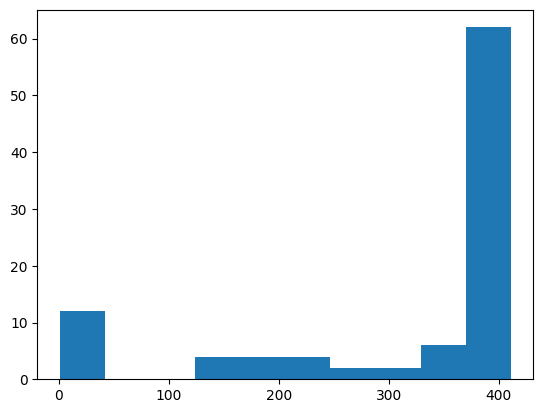

In [14]:
query={"data_tag" : "simple_stack_parallel"}
fold_list=list()
cursor = db.wf_TimeSeries.find(query)
for doc in cursor:
    # best to be safe rather than sorry with this test
    if "fold" in doc:
        fold_list.append(doc["fold"])
plt.hist(fold_list)
plt.show()

From that we can see most of these stacks have a fold over 300.   Use that as a cutoff and plot a few.

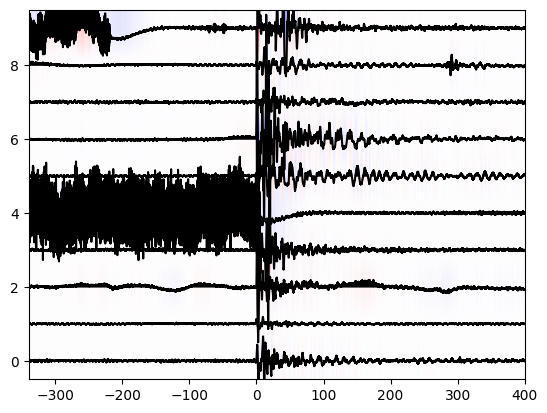

In [15]:
from mspasspy.algorithms.signals import detrend
plotter=SeismicPlotter(normalize=True)   # normalize essential here as the stacks are variable magnitude inputs
minimum_fold = 300    # see histogram above for guidance on size
query["fold"] = {"$gt" : minimum_fold}
cursor = db.wf_TimeSeries.find(query).limit(10)
ens = db.read_data(cursor)
ens = detrend(ens,type="demean")
plotter.plot(ens)

### Diagnosing Performance of Dask
The job above runs for several minutes.    While it is running we will expore each of the features noted below.   I'll point to what I mean by each of the following as I explain them:

#### Status Panel
The default window you see when you launch diagnostics is the "Status" page (you can get back to it by clicking the "Status" menu item in the upper left corner).  It is designed to be an overview page to monitor how things are going.   It is divided into five panels in two columns.  

*Upper left(column 1, row 1)*: displays total memory use by the running job.   If it goes yellow or red your job is in trouble.  That shouldn't happen here.
*Middle left (column 1, row 2)*:   shows memory use by each worker.   More color codes here.  See dask documentation for details, but as before yellow or red indicate trouble is brewing. 
*Lower left (column 1, row 3)*:  is used to monitor more details of what is happening with each worker.  Unlike the other widgets in this column it has a selectable set of options for different worker metrics to monitor in real time.  
*Upper right (column 2, row 1)*:  Status bar shows activity versus time.   That display is complex.  I'll talk about it while this is running but I highly recommend reading about details on in the dask documentation.  
*Lower right (column 2, row 2)*:   Titled "Progress" you will see the bar advancing as the job works through the data set.   

#### Menu Items
The front page of dask diagnostics also has a set of pulldown menu items.   All are useful, but you should examine at least two of them while your processing job runs.
1.   If you select the *Graph* item you get a useful display of the "DAG" for this workflow.   It shows you that this workflow is a type example of an "embarassingly parallel" workflow which is also sometimes called a "pipeline".  The DAG, in this case, is a set of parallel lines.  As the processing runs you will see boxes change color as they start, run, and complete.   Each box defines a single "partition" of the "bag" you learned about in the first notebook we worked through today.
2.   If you select *Profile* you get a visualization of data from a profiler dask diagnostics runs in real time.  For lack of time I won't discuss many details of how to interpret that graphic, but you should note that tool can be important in tuning a workflow to improve performance.   That is a more advanced use best pushed offline.  The dask documentation on this topic is excellent. 

### Discussion
Change the box below a "Raw" box to "Code".  Fill in your values for run time for the serial job from above and run time you got running the parallel job above.  We will have a brief discussion on parallel scaling.

One of the things that limited the performance of the workflow above is an issue with the normalize operators.  A detail about the two "matcher" objects we created that we assigned the symbols `site_matcher` and `source_matcher` is that both consume a fairly significant amount of memory.   The reason is they load up most of the content of the "site" and "source" collection into the data area of the associated object.  When we use them in the two calls to "normalize" the scheduler has to "serialize" each one on every single datum processed.   Dask has a solution to thiskind of problem in the client's `scatter` method.   It is easy to apply, but a bit mysterous in behavior. 

In [16]:
f_site_matcher = dask_client.scatter(site_matcher)
f_source_matcher = dask_client.scatter(source_matcher)

It is instructive to look at the type of the two things we just created:

In [17]:
print("Type of f_site_matcher=",type(f_site_matcher))
print("Type of f_source_matcher=",type(f_source_matcher))

Type of f_site_matcher= <class 'distributed.client.Future'>
Type of f_source_matcher= <class 'distributed.client.Future'>


They are not a copy of the original but a form of "Futures".  In fact, what happened is scatter pushed a single copy of both objects to all workers. When we run the revised workflow below you should note a new bar appeared on the "Progress" panel with the label "ObjectId".   That reflects what we just did with scatter. 

Here is the minor variant of above using the scattered data:

In [18]:
print("Number of ensembles to process=",len(srcid_list))

t0=time.time()
dataset = dbg.from_sequence(srcid_list)
dataset = dataset.map(query_generator)
dataset = dataset.map(parallel_reader,db.name)
dataset = dataset.map(detrend,type="demean")
dataset = dataset.map(normalize,f_site_matcher,handles_ensembles=False)
dataset = dataset.map(normalize,f_source_matcher,handles_ensembles=False)
dataset = dataset.map(rotate_to_standard)
dataset = dataset.map(set_PStime_ensemble)
dataset = dataset.map(applyFST_ensemble)
dataset = dataset.map(ator,"arrival_time")
dataset = dataset.map(ExtractComponent,2)
dataset = dataset.map(stack_ensemble)
dataset = dataset.map(parallel_writer,db.name,data_tag="simple_stack_parallel_scatter_run")
dataset=dataset.compute()
t = time.time()
print("Time to process = ",t-t0)

Number of ensembles to process= 48
Time to process =  453.378591299057


Noting the only changes are to the two "normalize" lines and I changed the data tag for the output.  

### Discussion
Did that reduce the processing time significantly?   If so how much?  If not, why?

## Sliding Window Algorithm
In the lecture I will give you background on the "Futures" API of dask.   Recall I noted that we have found that large data sets run with map/reduce often experienced memory problems caused by the dask scheduler tendency to oversubscribe the tasks it tries to process.   To remind you, our workflow is a case in point of why this happens.   The bag is initiated with a tiny list of source ids and terminates with a tiny output of the summary return of save_data.   Inside the processing pipeline the size of the data being handled in this workflow bloats by about 6 or 7 orders of magnitude.   In retrospect, it is not surprising dask has problems scheduling this kind of task.   We developed the sliding window algorithm with Futures as an alternative to handle typical pure pipeline workflows like this one.  A key feature of this approach compared to map/reduce is memory use is completely predictable.   The default "sliding window" size is 2 times the number of workers.   This workflow uses ensembles and from above we know their sizes up to about 400 members.   Consider it an exercise for the student to compute the maximum memory use from that and the nominal number of samples per ensemble member.   

There is a fundamental difference in how you structure your code to use the sliding_window_algorithm compared to map reduce.  The Futures interface used inside sliding_window_pipeline requires the processing to be bundled into a single function that we "submit" to the cluster for processing.   For this example, that means we want a function that starts from a source id value, does all the processing, and then saves the output before returning something which for our workflow is just the output of the parallel_writer function.   Here is a function that does that for our tutorial processing sequence.

In [19]:
def pipeline_function_example(srcid,dbname,site_matcher=None,source_matcher=None,data_tag="simple_stack_with_swp"):
    """
    This function demonstrates how to convert a sequence of bag map operator calls to a a single function 
    chaining the functions together to a single function that can be used with the Futures interface.  
    Used here for an example of the use of the sliding_window_pipeline function of MsPASS.  This function is derived 
    from this sequence:
    ----------------------------------------------------------------------------------------------------------------
    dataset = dbg.from_sequence(srcid_list)
    dataset = dataset.map(query_generator)
    dataset = dataset.map(parallel_reader,db.name)
    dataset = dataset.map(detrend,type="demean")
    dataset = dataset.map(normalize,site_matcher,handles_ensembles=False)
    dataset = dataset.map(normalize,source_matcher,handles_ensembles=False)
    dataset = dataset.map(rotate_to_standard)
    dataset = dataset.map(set_PStime_ensemble)
    dataset = dataset.map(applyFST_ensemble)
    dataset = dataset.map(ator,"Ptime")
    dataset = dataset.map(ExtractComponent,2)
    dataset = dataset.map(stack_ensemble)
    dataset = dataset.map(parallel_writer,db.name,data_tag="simple_stack_parallel")
    ----------------------------------------------------------------------------------------------------------------
    """
    # programming note - because this function is used only inside this notebook the baggage of argument validation
    # is omitted for speed.   That is bad practice in normal coding but appropriate here.  This comment is 
    # also a necessary thing if you do things like that
    query = query_generator(srcid)
    ens = parallel_reader(query,db.name)
    ens = detrend(ens,type="demean")
    ens = normalize(ens,site_matcher,handles_ensembles=False)
    ens = normalize(ens,source_matcher,handles_ensembles=False)
    ens = rotate_to_standard(ens)
    ens = set_PStime_ensemble(ens)
    ens = applyFST_ensemble(ens)
    ens = ator(ens,"arrival_time")
    ens = ExtractComponent(ens,2)
    stack = stack_ensemble(ens)
    # not required in python but good practice to release this memory immediately
    del ens
    save_output = parallel_writer(stack,dbname,data_tag=data_tag)
    return save_output

The `sliding_window_function` usage is a bit elaborate to make it generic.   The documentation for this function can be seen [here](https://www.mspass.org/python_api/mspasspy.workflow.html).  A summary useful to look at in this notebook is the function signature:
```

def sliding_window_pipeline(
    dlist,
    processing_function,
    dask_client,
    sliding_window_size="auto",
    task_per_worker=2,
    completion_function=None,
    accumulator=None,
    pfunc_args=None,
    pfunc_kwargs=None,
    cfunc_args=None,
    cfunc_kwargs=None,
    a_args=None,
    a_kwargs=None,
    verbose=False,
):
```

What I need to clarify here is the less than obvious way python handles arguments sent to a function in a wrapper function like sliding_window_pipeline.   In particular

- Required arguments (`pfunc_args` for `sliding_window_pipeline`) must given as python list
- Optional arguments (`pfunc_kwargs` for `sliding_window_pipeline`) must be given as a python dictionary with the keys being the **kwargs optional argument keys).

Kind of weird, I know, but necessary to understand this run line. Our last step is to run this variant. 

In [20]:
from mspasspy.workflow import sliding_window_pipeline
t0=time.time()
swpout = sliding_window_pipeline(srcid_list,
                                 pipeline_function_example,
                                 dask_client,
                                 pfunc_args=[db.name],
                                 pfunc_kwargs={"site_matcher" : f_site_matcher,
                                               "source_matcher" : f_source_matcher,
                                              }
                                )
t=time.time()
print("Run time for sliding_window_pipeline=",t-t0)
                                 

Run time for sliding_window_pipeline= 439.8519835472107


Note you can and should monior the dask diagnostics window while this runs.   Be aware it doesn't really report everything correctly.   Everything on the left is meaningful, but the Progress bar is meaningless.  The task stream for this job shows solid yellow, which incorrectly suggests the job is doing nothing but IO.   The Graph is meaningless but instructive.  It just shows 8 boxes for the 8 active Futures running at all time until the job completes.  